<h1 style="color:darkblue; font-size:36px;">Chewing on Change</h1>
<h2 style="color:gray; font-size:24px;">Lesson 4: Using machine learning models to assess variation in fossilized horse teeth for species classification</h2>

# Coding
Coding is the process of writing instructions for computers to follow. These instructions are written in a programming language, which is a set of rules and syntax that computers can understand. Coding allows us to create software, websites, apps, and more. For this activity, you do not need to know how to write code, but it is our hope that you can follow along and see what the code is expected to do.
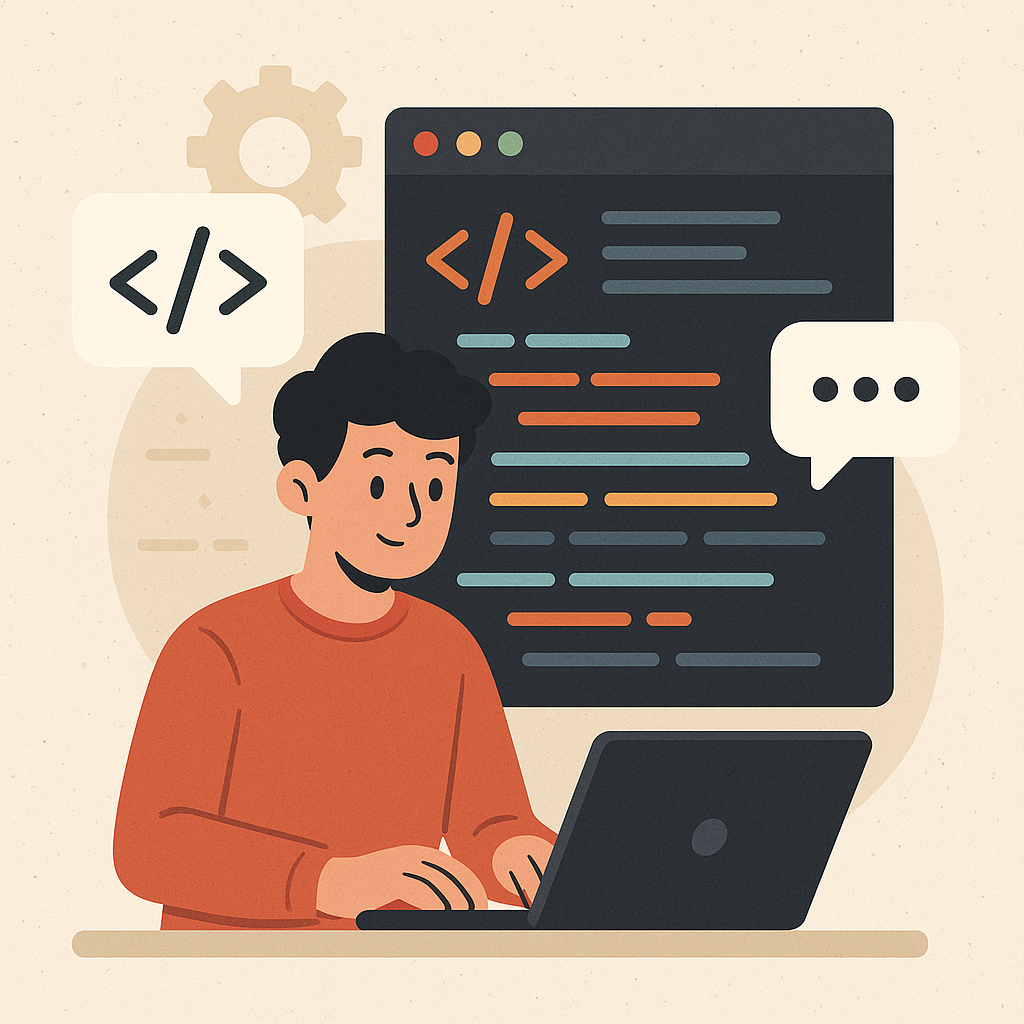

# Python
Python is a popular programming language known for its simplicity and readability. It's widely used in various fields, including web development, data analysis, artificial intelligence, and scientific computing. Python's syntax is designed to be easy to read and write, making it a great choice for beginners.

# Jupyter Notebook
A Jupyter Notebook is an open-source web application that allows you to create and share documents that contain live code, equations, visualizations, and narrative text. It's widely used in data science and machine learning for its interactive and user-friendly interface. You can write and execute Python code in a Jupyter Notebook, making it a powerful tool for experimentation and analysis. __This lesson is using a Jupyter Notebook!__

# Machine Learning
This assignment will use machine learning, a branch of artificial intelligence, that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed to perform a task, machine learning algorithms use statistical techniques to improve their performance over time as they are exposed to more data. Machine learning can be categorized into two main types: supervised (uses labeled data to learn from) and unsupervised learning (models the features of a dataset without any reference labels). All this to say, machine learning is a powerful tool for data exploration and analysis!
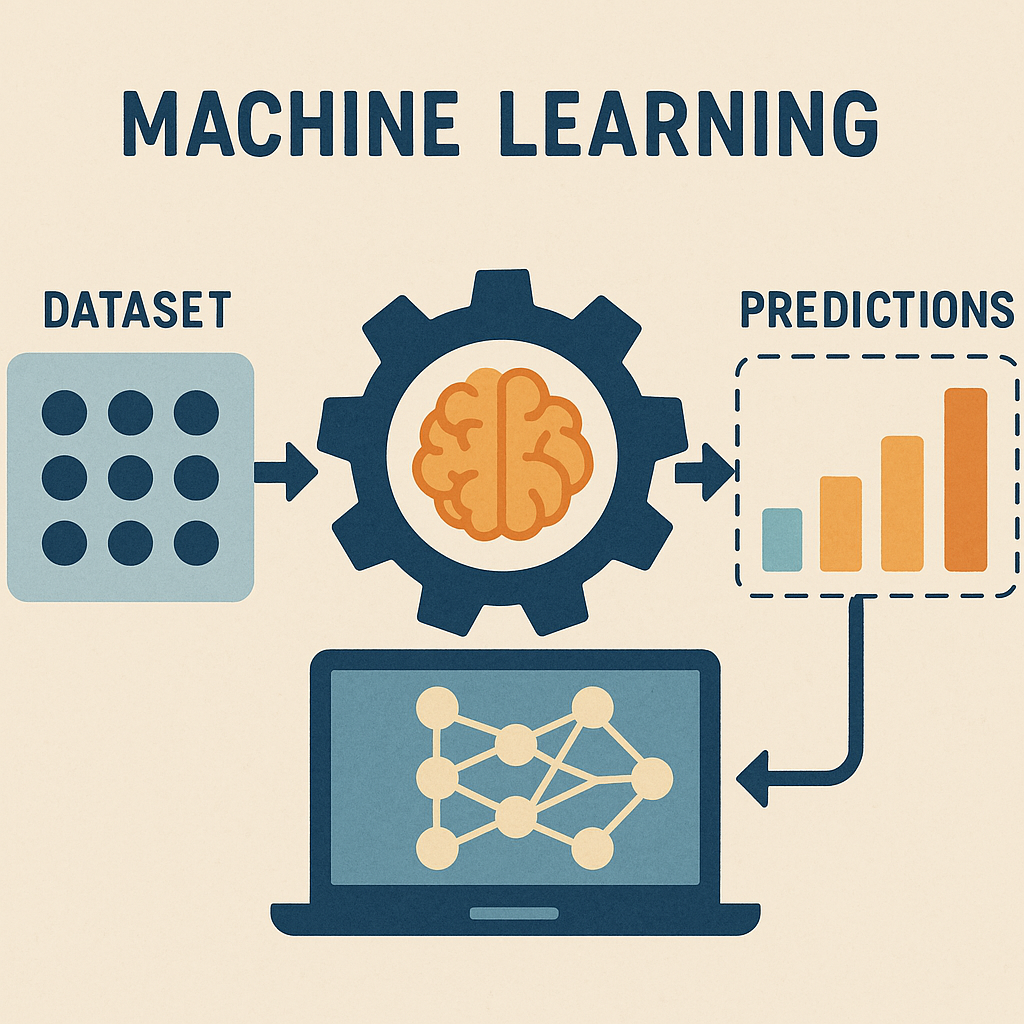

# CNNs (Convolutional Neural Networks)
A Convolutional Neural Network (CNN) is a type of deep learning algorithm that is particularly effective for analyzing visual data (images). CNNs are designed to automatically and adaptively learn features from images. They are widely used in image and video recognition, medical image analysis, and other areas where visual data is important.

__You will be testing how well CNNs do compared to humans in accurately identifying fossil horse species by visualizing images of their molar teeth. Do the CNN algorthim and computer vision model do as good or better than humans at identifying isolated teeth?__


# Let's Get Started!
For this exercise, we will explore image classification of upper molar teeth from three horse species: *Dinohippus interpolatus, Dinohippus mexicanus, and Equus simplicidens*. 

*We will be starting with a "simple" neural network with "convolusional" layers and data augmentation, a technique to increase the size and diversity of the training dataset, to build a better model. You will be able to compare your model results to how well your group was able to properly classify the horse tooth images provided at the start of the lesson. If time allows, try adjusting some of these parameters and rerunning the code. Does it change your results dramatically? If so, how?*

In [18]:
# !pip install torchvision  # Uncomment if torchvision is not installed

In [1]:
# This first bit of code imports the libraries and packages (bundle of different libraries) needed to perform the analysis. 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Set the device to CPU
device = torch.device("cpu")

In [21]:
# Define Image Transformations
transform = transforms.ToTensor()

In [22]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Force 1 channel
    transforms.ToTensor()
])

# Building the Model
Next, we will write the code to split our datasets for the six species folders into a training, validation, and test datasets for each species. The model will learn from the training dataset and make adjustments using the validation dataset, then the test dataset will be used for to see how well the image classification model does. 


In [23]:
# Load the Datasets

class FilteredImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None, filter_keyword="resized"):
        self.filter_keyword = filter_keyword
        super().__init__(root, transform=transform)

    def find_classes(self, directory):
        # Only include folders with 'resized' in the name
        classes = [d for d in os.listdir(directory)
                   if os.path.isdir(os.path.join(directory, d)) and self.filter_keyword in d]
        classes.sort()
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

data_dir = 'Image_Folder'
dataset = FilteredImageFolder(root=data_dir, transform=transform)

# Split into train and test sets
from torch.utils.data import random_split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create separate DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [24]:
# Define the CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),  # 128x128 → 64x64 → 32x32
            nn.ReLU(),
            nn.Linear(128, 5)  # 5 classes
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

In [25]:
# Initialize Model, Loss, Optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [1/10], Loss: 1.4407
Epoch [2/10], Loss: 1.1235
Epoch [3/10], Loss: 0.2792
Epoch [4/10], Loss: 0.7500
Epoch [5/10], Loss: 0.1120
Epoch [6/10], Loss: 0.0839
Epoch [7/10], Loss: 0.0094
Epoch [8/10], Loss: 0.0111
Epoch [9/10], Loss: 0.0673
Epoch [10/10], Loss: 0.0015


In [27]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 91.80%


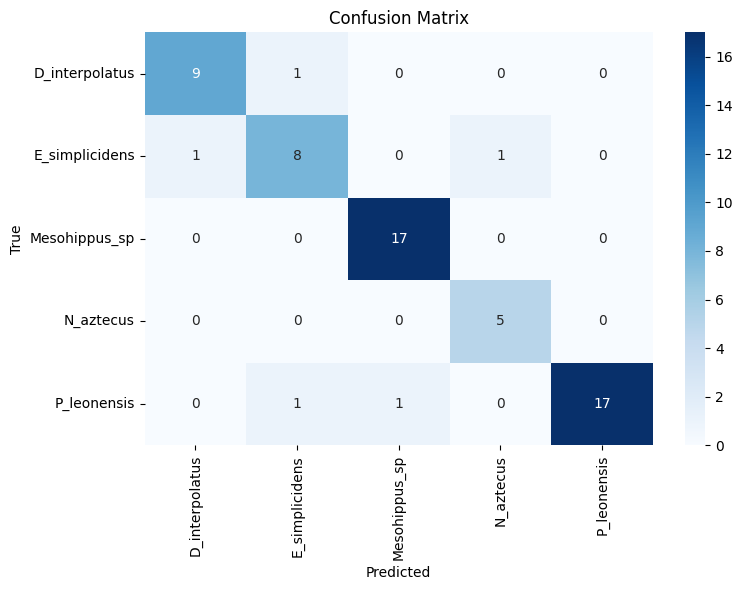

In [28]:
# Confusion Matrix
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model.eval()

# Collect predictions and true labels
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from dataset

# Shorten class labels by removing '_resized_gray'
class_names = [name.replace('_resized_gray', '') for name in dataset.classes]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [13]:
# Checking total number of images
print("Total images in dataset:", len(dataset))
print("Images in training set:", len(train_dataset))
print("Images in test set:", len(test_dataset))

Total images in dataset: 304
Images in training set: 243
Images in test set: 61


# Where Does Our Model Struggle Most?
We can review a confusion matrix to display what the model predicted versus the true labels for the images in our datasets. From these results, we may want to fine-tune our model more and re-run things to make the model perform better.

# Let's Test the Model
Now let's load a test dataset that has not been seen by the model up to now. 